In [2]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings("ignore")

shap.initjs()

### Load the best model and test data  

In [3]:
best_model = joblib.load("../models/best_model.pkl")
X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv").squeeze()

print("Model type:", type(best_model).__name__)
print("X_test shape:", X_test.shape)

Model type: LinearRegression
X_test shape: (199954, 27)


In [4]:
# SHAP computations scale poorly with row count — use a representative sample
X_shap_sample = X_test.sample(2000, random_state=42)

print("SHAP sample shape:", X_shap_sample.shape)

SHAP sample shape: (2000, 27)


In [5]:
model_type = type(best_model).__name__

if model_type == "LinearRegression":
    explainer = shap.LinearExplainer(best_model, X_shap_sample)
    shap_values = explainer(X_shap_sample)
elif model_type in ["XGBRegressor", "LGBMRegressor", "DecisionTreeRegressor"]:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer(X_shap_sample)
else:
    explainer = shap.Explainer(best_model, X_shap_sample)
    shap_values = explainer(X_shap_sample)

print("SHAP values computed. Shape:", shap_values.values.shape)

Background dataset has 2000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2000 when initializing the masker.


SHAP values computed. Shape: (2000, 27)


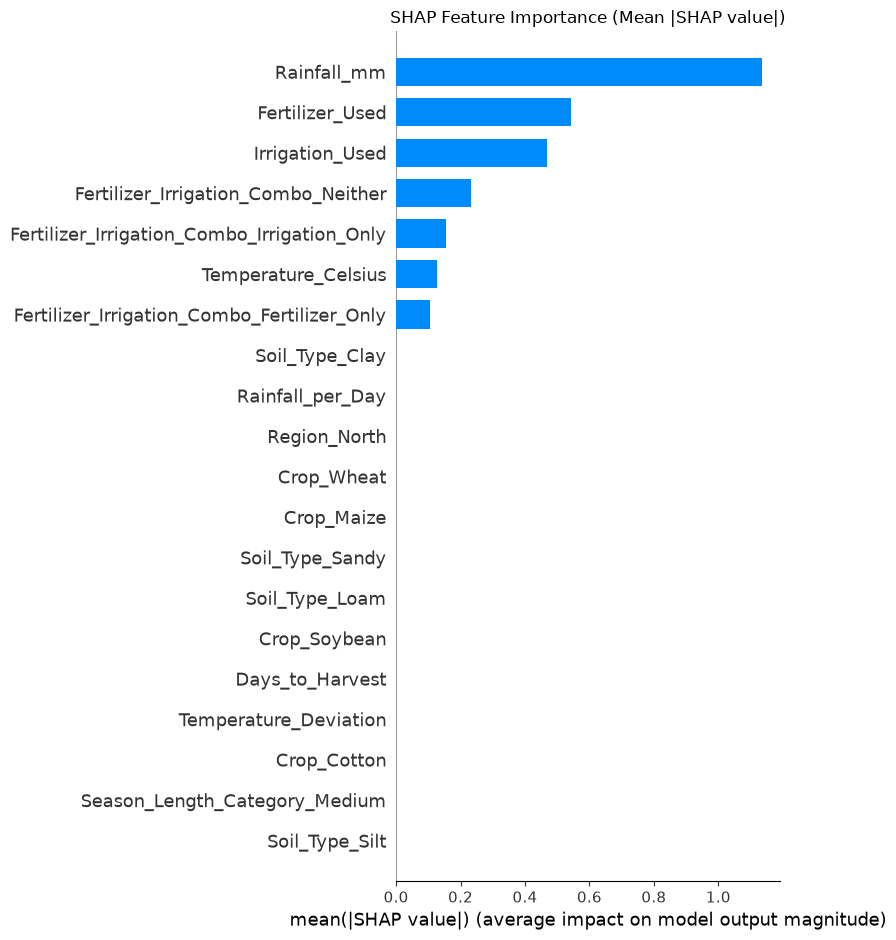

In [6]:
### SHAP Summary Plot    
plt.figure()
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP value|)")
plt.tight_layout()
plt.savefig("../reports/figures/17_shap_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()

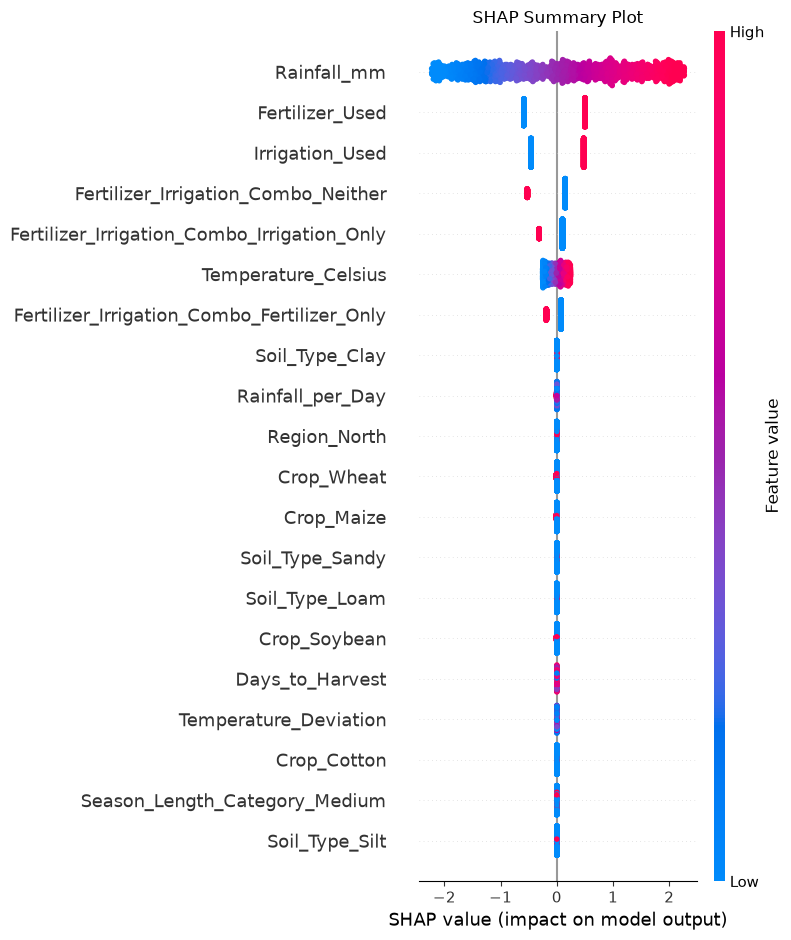

In [7]:
# SHAP Summary Plot (dot — shows direction and distribution)    
plt.figure()
shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.savefig("../reports/figures/18_shap_summary_dot.png", dpi=150, bbox_inches="tight")
plt.show()

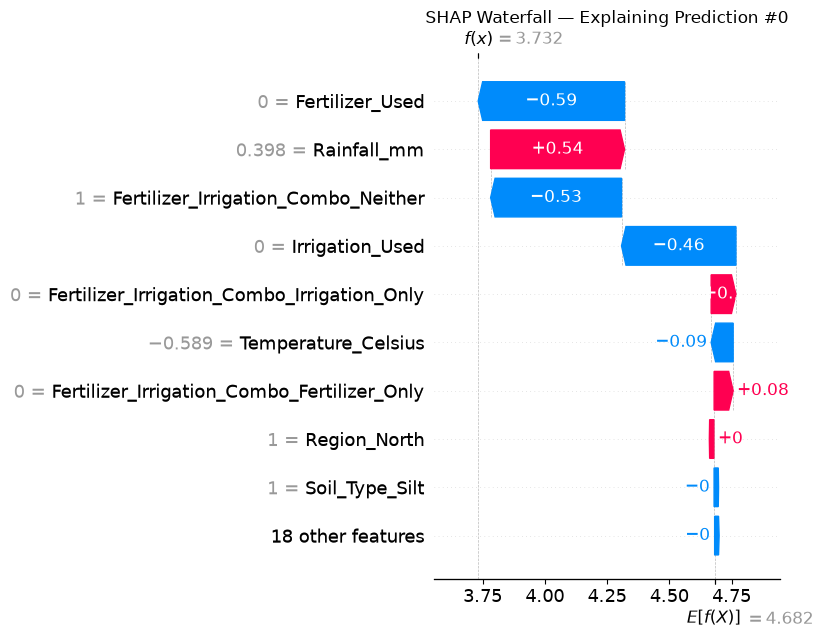

Actual value for this row: 3.761811118487432
Predicted value: 3.7321259397555977


In [8]:
### SHAP Waterfall Plot


sample_idx = 0

plt.figure()
shap.plots.waterfall(shap_values[sample_idx], show=False)
plt.title(f"SHAP Waterfall — Explaining Prediction #{sample_idx}")
plt.tight_layout()
plt.savefig("../reports/figures/19_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

print("Actual value for this row:", y_test.loc[X_shap_sample.index[sample_idx]])
print("Predicted value:", best_model.predict(X_shap_sample.iloc[[sample_idx]])[0])

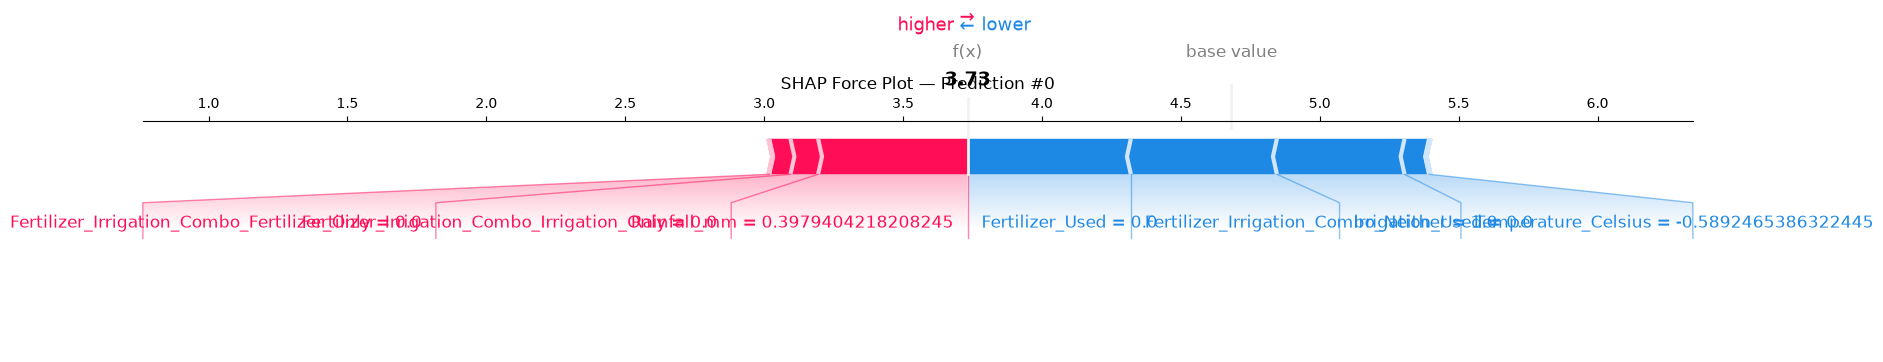

In [9]:
### SHAP Force Plot

force_plot = shap.plots.force(shap_values[sample_idx], matplotlib=True, show=False)
plt.title(f"SHAP Force Plot — Prediction #{sample_idx}")
plt.savefig("../reports/figures/20_shap_force_plot.png", dpi=150, bbox_inches="tight")
plt.show()

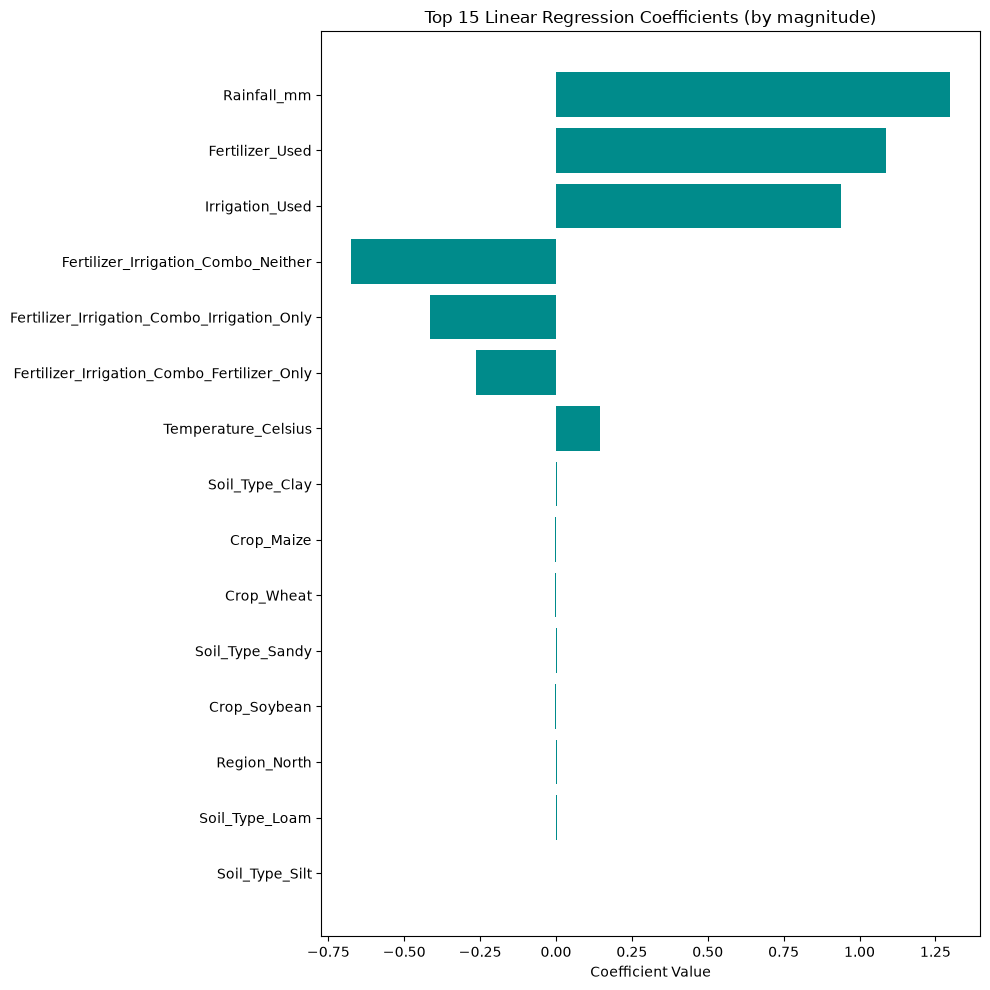

                                        Feature  Coefficient
0                                   Rainfall_mm     1.298257
2                               Fertilizer_Used     1.088594
3                               Irrigation_Used     0.937683
24          Fertilizer_Irrigation_Combo_Neither    -0.674006
23  Fertilizer_Irrigation_Combo_Irrigation_Only    -0.414589
22  Fertilizer_Irrigation_Combo_Fertilizer_Only    -0.263678
1                           Temperature_Celsius     0.143907
10                               Soil_Type_Clay     0.003498
16                                   Crop_Maize    -0.003066
19                                   Crop_Wheat    -0.002675
13                              Soil_Type_Sandy     0.002633
18                                 Crop_Soybean    -0.002042
7                                  Region_North     0.001926
11                               Soil_Type_Loam     0.001855
14                               Soil_Type_Silt    -0.001316


In [10]:
# Feature Importance

if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    plt.figure(figsize=(10, 10))
    plt.barh(importance_df["Feature"][:15][::-1], importance_df["Importance"][:15][::-1], color="teal")
    plt.title(f"Top 15 Feature Importances — {model_type}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("../reports/figures/21_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(importance_df.head(15))

elif hasattr(best_model, "coef_"):
    importance_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Coefficient": best_model.coef_
    }).sort_values("Coefficient", key=abs, ascending=False)

    plt.figure(figsize=(10, 10))
    plt.barh(importance_df["Feature"][:15][::-1], importance_df["Coefficient"][:15][::-1], color="darkcyan")
    plt.title("Top 15 Linear Regression Coefficients (by magnitude)")
    plt.xlabel("Coefficient Value")
    plt.tight_layout()
    plt.savefig("../reports/figures/21_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(importance_df.head(15))

### Permutation Importance  

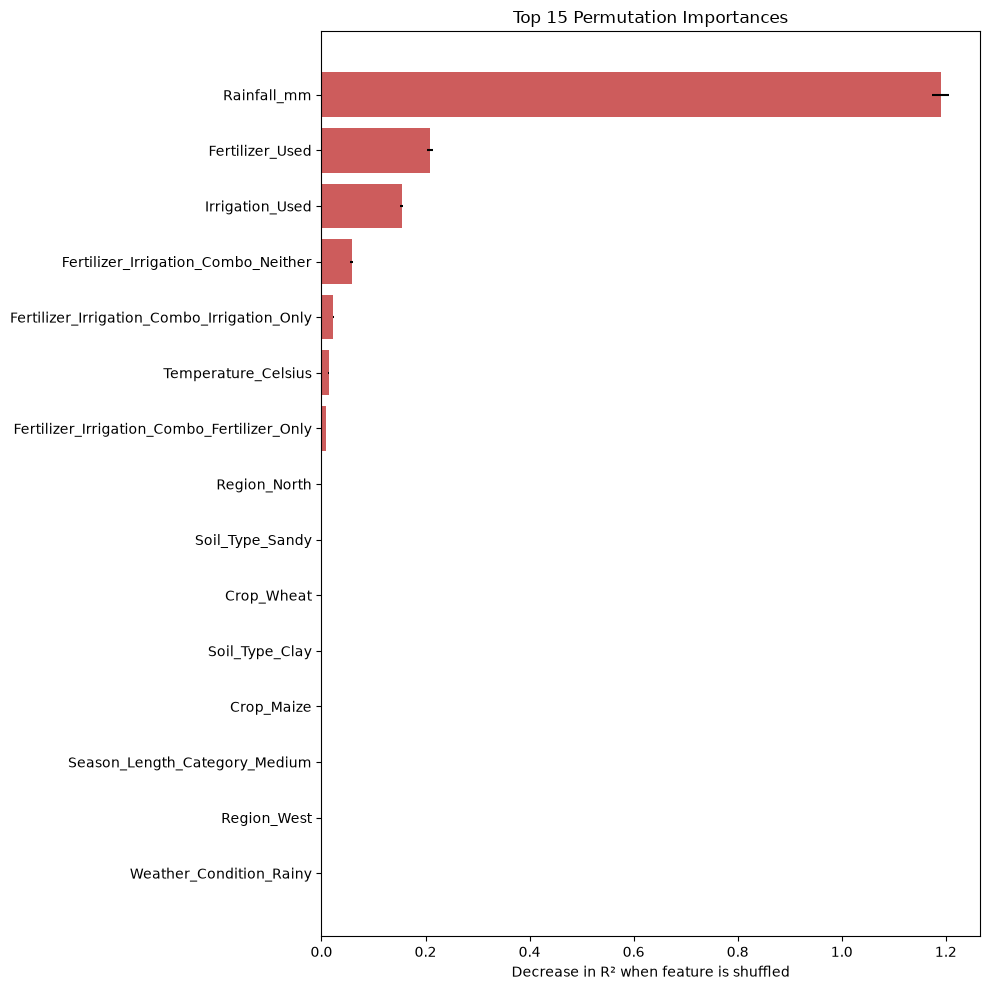

                                        Feature  Importance_Mean  \
0                                   Rainfall_mm     1.189873e+00   
2                               Fertilizer_Used     2.088010e-01   
3                               Irrigation_Used     1.544051e-01   
24          Fertilizer_Irrigation_Combo_Neither     5.787282e-02   
23  Fertilizer_Irrigation_Combo_Irrigation_Only     2.291080e-02   
1                           Temperature_Celsius     1.412083e-02   
22  Fertilizer_Irrigation_Combo_Fertilizer_Only     8.938601e-03   
7                                  Region_North     8.361214e-06   
13                              Soil_Type_Sandy     5.455764e-06   
19                                   Crop_Wheat     4.885111e-06   
10                               Soil_Type_Clay     3.011897e-06   
16                                   Crop_Maize     2.613287e-06   
25                Season_Length_Category_Medium     2.208715e-06   
9                                   Region_West 

In [11]:
from sklearn.inspection import permutation_importance

X_perm_sample = X_test.sample(5000, random_state=42)
y_perm_sample = y_test.loc[X_perm_sample.index]

perm_result = permutation_importance(best_model, X_perm_sample, y_perm_sample,
                                      n_repeats=5, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
}).sort_values("Importance_Mean", ascending=False)

plt.figure(figsize=(10, 10))
plt.barh(perm_df["Feature"][:15][::-1], perm_df["Importance_Mean"][:15][::-1],
         xerr=perm_df["Importance_Std"][:15][::-1], color="indianred")
plt.title("Top 15 Permutation Importances")
plt.xlabel("Decrease in R² when feature is shuffled")
plt.tight_layout()
plt.savefig("../reports/figures/22_permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(perm_df.head(15))

### Cross-check   

In [12]:
top_shap = pd.DataFrame({
    "Feature": X_shap_sample.columns,
    "Mean_Abs_SHAP": np.abs(shap_values.values).mean(axis=0)
}).sort_values("Mean_Abs_SHAP", ascending=False).head(10)["Feature"].tolist()

top_perm = perm_df.head(10)["Feature"].tolist()

print("Top 10 features by SHAP:")
print(top_shap)
print("\nTop 10 features by Permutation Importance:")
print(top_perm)
print("\nOverlap:", set(top_shap) & set(top_perm))

Top 10 features by SHAP:
['Rainfall_mm', 'Fertilizer_Used', 'Irrigation_Used', 'Fertilizer_Irrigation_Combo_Neither', 'Fertilizer_Irrigation_Combo_Irrigation_Only', 'Temperature_Celsius', 'Fertilizer_Irrigation_Combo_Fertilizer_Only', 'Soil_Type_Clay', 'Rainfall_per_Day', 'Region_North']

Top 10 features by Permutation Importance:
['Rainfall_mm', 'Fertilizer_Used', 'Irrigation_Used', 'Fertilizer_Irrigation_Combo_Neither', 'Fertilizer_Irrigation_Combo_Irrigation_Only', 'Temperature_Celsius', 'Fertilizer_Irrigation_Combo_Fertilizer_Only', 'Region_North', 'Soil_Type_Sandy', 'Crop_Wheat']

Overlap: {'Temperature_Celsius', 'Irrigation_Used', 'Fertilizer_Irrigation_Combo_Neither', 'Fertilizer_Irrigation_Combo_Fertilizer_Only', 'Fertilizer_Used', 'Fertilizer_Irrigation_Combo_Irrigation_Only', 'Rainfall_mm', 'Region_North'}


In [13]:
import json

xai_summary = {
    "model_explained": model_type,
    "shap_sample_size": len(X_shap_sample),
    "top_10_features_shap": top_shap,
    "top_10_features_permutation": top_perm,
    "agreement_count": len(set(top_shap) & set(top_perm)),
    "notes": (
        "SHAP and permutation importance were computed on the selected best model "
        "to identify and validate the most influential features. Strong agreement "
        "between methods indicates stable, genuine feature relationships rather "
        "than artifacts of a single explanation technique."
    )
}

with open("../reports/explainability_summary.json", "w") as f:
    json.dump(xai_summary, f, indent=4)

xai_summary

{'model_explained': 'LinearRegression',
 'shap_sample_size': 2000,
 'top_10_features_shap': ['Rainfall_mm',
  'Fertilizer_Used',
  'Irrigation_Used',
  'Fertilizer_Irrigation_Combo_Neither',
  'Fertilizer_Irrigation_Combo_Irrigation_Only',
  'Temperature_Celsius',
  'Fertilizer_Irrigation_Combo_Fertilizer_Only',
  'Soil_Type_Clay',
  'Rainfall_per_Day',
  'Region_North'],
 'top_10_features_permutation': ['Rainfall_mm',
  'Fertilizer_Used',
  'Irrigation_Used',
  'Fertilizer_Irrigation_Combo_Neither',
  'Fertilizer_Irrigation_Combo_Irrigation_Only',
  'Temperature_Celsius',
  'Fertilizer_Irrigation_Combo_Fertilizer_Only',
  'Region_North',
  'Soil_Type_Sandy',
  'Crop_Wheat'],
 'agreement_count': 8,
 'notes': 'SHAP and permutation importance were computed on the selected best model to identify and validate the most influential features. Strong agreement between methods indicates stable, genuine feature relationships rather than artifacts of a single explanation technique.'}

In [14]:
# Save the SHAP explainer object for use in the API

import pickle

# Save a small background sample + explainer setup info for reuse in FastAPI
# (Full SHAP explainer objects can be large; we save what's needed to reconstruct explanations)
with open("../models/preprocessing/shap_background_sample.pkl", "wb") as f:
    pickle.dump(X_shap_sample.sample(100, random_state=42), f)

print("SHAP background sample saved for API use.")
print("Model type for API reference:", model_type)

SHAP background sample saved for API use.
Model type for API reference: LinearRegression


In [ ]:
engineered_features = ["Rainfall_per_Day", "Temperature_Deviation", "Season_Length_Category_Medium",
                        "Season_Length_Category_Short"]

engineered_in_top15 = [f for f in engineered_features if f in top_shap or f in top_perm]

print("Engineered features that made it into top 15 importance:", engineered_in_top15)
print("\nConclusion: Rainfall_per_Day and Temperature_Deviation did not add meaningful signal "
      "beyond their raw counterparts (Rainfall_mm, Temperature_Celsius), consistent with the "
      "weaker correlation observed during feature engineering. The Fertilizer_Irrigation_Combo "
      "interaction feature, however, proved valuable and ranks among the top contributors.")